Optimal offline matching size: 10
Training RL+RNN agent...
Episode 500, reward: 10.00
Episode 1000, reward: 9.00
Episode 1500, reward: 9.00
Episode 2000, reward: 10.00
Evaluating algorithms...
Greedy: avg_reward=9.01, competitive_ratio=0.901
Random: avg_reward=8.98, competitive_ratio=0.898
ε‑RANKING: avg_reward=8.95, competitive_ratio=0.895
RL+RNN: avg_reward=9.20, competitive_ratio=0.920


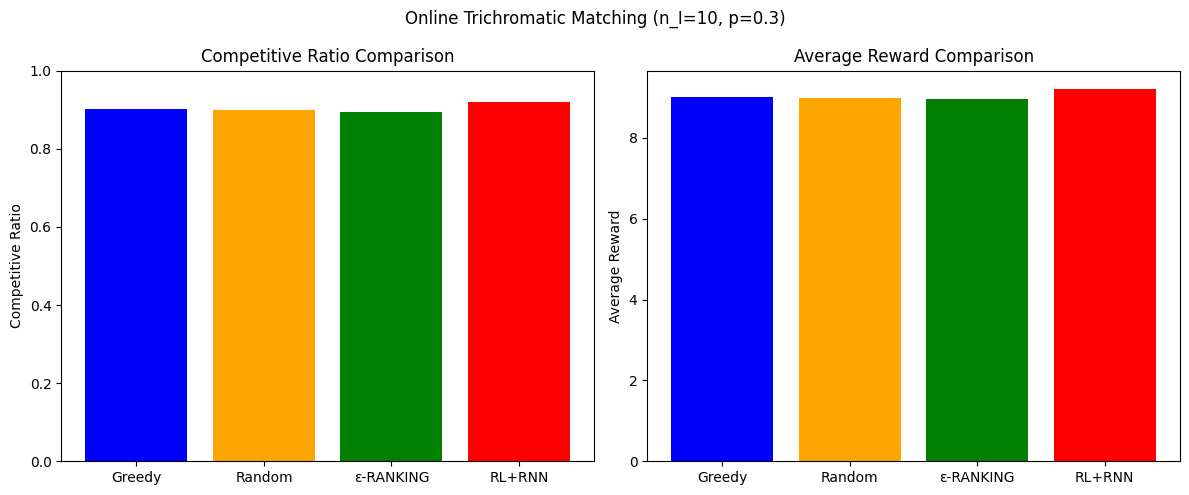


Detailed results:
Greedy       | Reward:   9.01 | CR: 0.9010
Random       | Reward:   8.98 | CR: 0.8980
ε‑RANKING    | Reward:   8.95 | CR: 0.8950
RL+RNN       | Reward:   9.20 | CR: 0.9200


In [ ]:
"""
Online Trichromatic Matching: Comparative Study
================================================
Algorithms:
- Greedy (deterministic, 1/3 worst‑case competitive ratio)
- Randomized ε‑RANKING (1/e ≈ 0.37 competitive ratio)
- RL+RNN agent (policy gradient with LSTM)
- Random baseline

Metrics:
- Competitive ratio = algorithm reward / optimal offline reward
- Average reward
- Matching size
"""

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random
import matplotlib.pyplot as plt
from typing import List, Tuple, Set, Dict, Optional
import networkx as nx
from scipy.sparse.csgraph import maximum_bipartite_matching
import itertools

# ============================================================================
# 1. Environment: Online Trichromatic Matching
# ============================================================================

class TripartiteGraph:
    """Represents a tripartite graph with sets L, I, R."""
    def __init__(self, n_I: int, edges_L: List[Tuple[int, int]], edges_R: List[Tuple[int, int]]):
        self.n_I = n_I
        self.n_L = max([l for l, _ in edges_L]) + 1 if edges_L else 0
        self.n_R = max([r for _, r in edges_R]) + 1 if edges_R else 0

        self.adj_L = [[] for _ in range(n_I)]
        self.adj_R = [[] for _ in range(n_I)]
        for l, i in edges_L:
            self.adj_L[i].append(l)
        for i, r in edges_R:
            self.adj_R[i].append(r)

        self.L_neighbors = [[] for _ in range(self.n_L)]
        for l, i in edges_L:
            self.L_neighbors[l].append(i)
        self.R_neighbors = [[] for _ in range(self.n_R)]
        for i, r in edges_R:
            self.R_neighbors[r].append(i)

    def get_offline_optimal_matching_size(self) -> int:
        nL, nI, nR = self.n_L, self.n_I, self.n_R
        total_nodes = 2 + nL + nI + nR
        source = 0
        sink = total_nodes - 1
        offset_L = 1
        offset_I = offset_L + nL
        offset_R = offset_I + nI

        G = nx.DiGraph()
        for l in range(nL):
            G.add_edge(source, offset_L + l, capacity=1)
            for i in self.L_neighbors[l]:
                G.add_edge(offset_L + l, offset_I + i, capacity=1)
        for i in range(nI):
            for r in self.R_neighbors[i]:
                G.add_edge(offset_I + i, offset_R + r, capacity=1)
        for r in range(nR):
            G.add_edge(offset_R + r, sink, capacity=1)

        flow_value, _ = nx.maximum_flow(G, source, sink)
        return flow_value


class OnlineMatchingEnv:
    def __init__(self, graph: TripartiteGraph, arrival_order: List[Tuple[str, int]]):
        self.graph = graph
        self.arrival_order = arrival_order  # list of ('L', id) or ('R', id)
        self.n_I = graph.n_I

        # State tracking
        self.I_state = np.zeros(self.n_I, dtype=int)  # 0: unmatched, 1: waiting L, 2: waiting R
        self.waiting_for_I = {}  # I -> (type, online_id) for nodes waiting
        self.matched_triples = []  # list of (l, i, r)
        self.used_L = set()
        self.used_R = set()
        self.used_I = set()

        self.current_step = 0
        self.done = False

    def reset(self):
        self.I_state = np.zeros(self.n_I, dtype=int)
        self.waiting_for_I = {}
        self.matched_triples = []
        self.used_L = set()
        self.used_R = set()
        self.used_I = set()
        self.current_step = 0
        self.done = False
        return self._get_state()

    def _get_state(self) -> dict:
        return {
            'I_state': self.I_state.copy(),
            'waiting_for_I': self.waiting_for_I.copy(),
            'used_L': self.used_L.copy(),
            'used_R': self.used_R.copy(),
            'used_I': self.used_I.copy(),
            'current_online': self.arrival_order[self.current_step] if not self.done else None
        }

    def step(self, action: Optional[int]) -> Tuple[dict, float, bool]:
        if self.done:
            raise RuntimeError("Episode already done")

        online_type, online_id = self.arrival_order[self.current_step]
        reward = 0.0

        # Get eligible I nodes for matching (those that already have waiting opposite side)
        eligible_I = []
        if online_type == 'L':
            # L arrives: can match with I that have waiting R
            for i in self.graph.L_neighbors[online_id]:
                if i not in self.used_I and self.I_state[i] == 2:  # waiting R
                    eligible_I.append(i)
        else:  # 'R'
            for i in self.graph.R_neighbors[online_id]:
                if i not in self.used_I and self.I_state[i] == 1:  # waiting L
                    eligible_I.append(i)

        # Process action
        if action is not None and action in eligible_I:
            i = action
            # Form triple
            if online_type == 'L':
                waiting_type, waiting_id = self.waiting_for_I[i]
                assert waiting_type == 'R'
                triple = (online_id, i, waiting_id)
            else:
                waiting_type, waiting_id = self.waiting_for_I[i]
                assert waiting_type == 'L'
                triple = (waiting_id, i, online_id)

            self.matched_triples.append(triple)
            self.used_L.add(triple[0])
            self.used_I.add(i)
            self.used_R.add(triple[2])
            self.I_state[i] = 0  # matched
            del self.waiting_for_I[i]
            reward = 1.0

        # Update waiting lists if no match was made
        if reward == 0.0:
            # Current node becomes waiting
            if online_type == 'L':
                for i in self.graph.L_neighbors[online_id]:
                    if i not in self.used_I and self.I_state[i] == 0:
                        self.I_state[i] = 1  # waiting L
                        self.waiting_for_I[i] = ('L', online_id)
            else:  # 'R'
                for i in self.graph.R_neighbors[online_id]:
                    if i not in self.used_I and self.I_state[i] == 0:
                        self.I_state[i] = 2  # waiting R
                        self.waiting_for_I[i] = ('R', online_id)

        self.current_step += 1
        if self.current_step >= len(self.arrival_order):
            self.done = True

        next_state = self._get_state() if not self.done else None
        return next_state, reward, self.done

    def get_total_reward(self) -> int:
        return len(self.matched_triples)


# ============================================================================
# 2. Algorithms
# ============================================================================

class BaseAlgorithm:
    def select_action(self, env: OnlineMatchingEnv, online_type: str, online_id: int,
                      eligible_I: List[int], **kwargs) -> Optional[int]:
        raise NotImplementedError

    def run_episode(self, env: OnlineMatchingEnv) -> int:
        env.reset()
        while not env.done:
            online_type, online_id = env.arrival_order[env.current_step]
            state = env._get_state()
            eligible_I = self._get_eligible_I(env, online_type, online_id)
            action = self.select_action(env, online_type, online_id, eligible_I, state=state)
            _, _, _ = env.step(action)
        return env.get_total_reward()

    def _get_eligible_I(self, env: OnlineMatchingEnv, online_type: str, online_id: int) -> List[int]:
        eligible = []
        if online_type == 'L':
            for i in env.graph.L_neighbors[online_id]:
                if i not in env.used_I and env.I_state[i] == 2:
                    eligible.append(i)
        else:
            for i in env.graph.R_neighbors[online_id]:
                if i not in env.used_I and env.I_state[i] == 1:
                    eligible.append(i)
        return eligible


class GreedyAlgorithm(BaseAlgorithm):
    def select_action(self, env, online_type, online_id, eligible_I, **kwargs):
        return eligible_I[0] if eligible_I else None


class RandomAlgorithm(BaseAlgorithm):
    def select_action(self, env, online_type, online_id, eligible_I, **kwargs):
        return random.choice(eligible_I) if eligible_I else None


class EpsilonRankingAlgorithm(BaseAlgorithm):
    def __init__(self, n_I: int, seed: int = 42):
        self.n_I = n_I
        self.rng = np.random.RandomState(seed)
        # Assign random ranks to offline vertices
        self.ranks = self.rng.uniform(0, 1, n_I)

    def select_action(self, env, online_type, online_id, eligible_I, **kwargs):
        if not eligible_I:
            return None

        # Find the neighbor with minimum rank among ALL neighbors (eligible or not)
        all_neighbors = env.graph.L_neighbors[online_id] if online_type == 'L' else env.graph.R_neighbors[online_id]
        # Filter unmatched
        available_neighbors = [i for i in all_neighbors if i not in env.used_I]
        if not available_neighbors:
            return None

        lowest_rank_idx = min(available_neighbors, key=lambda i: self.ranks[i])
        lowest_rank = self.ranks[lowest_rank_idx]

        # Check if lowest rank neighbor is eligible (has opposite side waiting)
        if lowest_rank_idx in eligible_I:
            # Case 2: match with lowest rank, ε=0
            return lowest_rank_idx
        else:
            # Case 3: lowest rank not eligible; pick eligible neighbor with smallest rank > lowest_rank
            # (minimizing ε = rank(is) - rank(io))
            eligible_with_rank = [(i, self.ranks[i]) for i in eligible_I if self.ranks[i] > lowest_rank]
            if eligible_with_rank:
                best_i = min(eligible_with_rank, key=lambda x: x[1] - lowest_rank)[0]
                return best_i
            else:
                # No eligible with higher rank; skip (or could match arbitrarily, but paper implies skip)
                return None


# ============================================================================
# 3. RL+RNN Agent (Policy Gradient with LSTM)
# ============================================================================

class RNNPolicyNetwork(nn.Module):
    """
    Policy network with LSTM to process sequence of arrivals.
    Outputs logits over actions (which I to match, or skip).
    """
    def __init__(self, n_I: int, hidden_dim: int = 128):
        super().__init__()
        self.n_I = n_I

        # Input features per step:
        # - online_type: 2-dim one-hot (L/R)
        # - online_neighbors: n_I-dim binary vector
        # - I_state: n_I-dim (0/1/2) one-hot encoded -> 3*n_I
        # - normalized step
        input_dim = 2 + n_I + 3 * n_I + 1

        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, n_I + 1)  # +1 for skip action

    def forward(self, seq_features, hidden=None):
        """
        seq_features: (batch, seq_len, input_dim)
        Returns: logits (batch, seq_len, n_I+1), hidden
        """
        lstm_out, hidden = self.lstm(seq_features, hidden)
        logits = self.fc(lstm_out)
        return logits, hidden

    def init_hidden(self, batch_size=1):
        h = torch.zeros(1, batch_size, self.lstm.hidden_size)
        c = torch.zeros(1, batch_size, self.lstm.hidden_size)
        return (h, c)


class RLRNNAgent(BaseAlgorithm):
    """
    RL agent that uses an LSTM policy to decide matching actions.
    Trained via REINFORCE with baseline.
    """
    def __init__(self, n_I: int, hidden_dim=128, lr=1e-3, gamma=0.99, device='cpu'):
        self.n_I = n_I
        self.device = torch.device(device)
        self.policy_net = RNNPolicyNetwork(n_I, hidden_dim).to(self.device)
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.gamma = gamma

        # For training
        self.saved_log_probs = []
        self.rewards = []
        self.baseline = 0.0
        self.beta = 0.9  # for baseline update

    def _encode_state(self, state: dict, online_type: str, online_id: int) -> torch.Tensor:
        """Convert state to feature vector."""
        # online_type one-hot
        type_vec = np.array([1, 0]) if online_type == 'L' else np.array([0, 1])

        # neighbors binary vector
        neigh_vec = np.zeros(self.n_I)
        if online_type == 'L':
            for i in state['current_online'][2]:  # need neighbors; we'll pass separately
                pass  # handled below
        # Actually we need neighbors from env. Better to pass neighbors list.

        # I_state one-hot (0/1/2 -> 3 dims)
        I_state = state['I_state']
        I_state_onehot = np.zeros(3 * self.n_I)
        for i in range(self.n_I):
            I_state_onehot[3*i + I_state[i]] = 1

        # normalized step
        step_norm = np.array([state.get('step', 0) / 100.0])  # approximate normalization

        # Combine
        # For simplicity, we'll build features inside select_action using env info.
        # Here we return placeholder.
        return None

    def _build_features(self, env: OnlineMatchingEnv, online_type: str, online_id: int) -> torch.Tensor:
        """Construct feature vector for current step."""
        # online type one-hot
        type_onehot = [1, 0] if online_type == 'L' else [0, 1]

        # neighbor mask
        if online_type == 'L':
            neighbors = env.graph.L_neighbors[online_id]
        else:
            neighbors = env.graph.R_neighbors[online_id]
        neigh_mask = np.zeros(self.n_I)
        for i in neighbors:
            neigh_mask[i] = 1.0

        # I state one-hot
        I_state = env.I_state
        I_state_onehot = np.zeros(3 * self.n_I)
        for i in range(self.n_I):
            I_state_onehot[3*i + I_state[i]] = 1.0

        # step
        step_norm = np.array([env.current_step / len(env.arrival_order)])

        feature = np.concatenate([type_onehot, neigh_mask, I_state_onehot, step_norm])
        return torch.tensor(feature, dtype=torch.float32).unsqueeze(0).to(self.device)  # (1, input_dim)

    def select_action(self, env, online_type, online_id, eligible_I, state=None, hidden=None, training=False):
        # Build feature
        feat = self._build_features(env, online_type, online_id)  # (1, input_dim)
        # Add batch and seq dimensions
        feat = feat.unsqueeze(0)  # (1, seq_len=1, input_dim)

        if hidden is None:
            hidden = self.policy_net.init_hidden(batch_size=1)
            hidden = (hidden[0].to(self.device), hidden[1].to(self.device))

        logits, hidden = self.policy_net(feat, hidden)
        logits = logits.squeeze(0).squeeze(0)  # (n_I+1,)

        # Mask invalid actions
        mask = torch.full((self.n_I + 1,), -1e9, device=self.device)
        # skip action always allowed
        mask[-1] = 0
        for i in eligible_I:
            mask[i] = 0
        masked_logits = logits + mask

        probs = torch.softmax(masked_logits, dim=-1)
        if training:
            m = torch.distributions.Categorical(probs)
            action_idx = m.sample()
            self.saved_log_probs.append(m.log_prob(action_idx))
        else:
            action_idx = torch.argmax(probs)

        action = action_idx.item()
        if action == self.n_I:  # skip
            return None, hidden
        else:
            return action, hidden

    def train_episode(self, env: OnlineMatchingEnv):
        """Run one episode for training, collect rewards and log probs."""
        env.reset()
        hidden = self.policy_net.init_hidden(batch_size=1)
        hidden = (hidden[0].to(self.device), hidden[1].to(self.device))
        episode_rewards = []

        while not env.done:
            online_type, online_id = env.arrival_order[env.current_step]
            state = env._get_state()
            eligible_I = self._get_eligible_I(env, online_type, online_id)

            action, hidden = self.select_action(env, online_type, online_id, eligible_I,
                                                state, hidden, training=True)
            _, reward, _ = env.step(action)
            episode_rewards.append(reward)

        # Compute discounted returns
        R = 0
        returns = []
        for r in reversed(episode_rewards):
            R = r + self.gamma * R
            returns.insert(0, R)
        returns = torch.tensor(returns, device=self.device)

        # Update baseline
        self.baseline = self.beta * self.baseline + (1 - self.beta) * returns.mean().item()

        # Policy gradient
        policy_loss = []
        for log_prob, R in zip(self.saved_log_probs, returns):
            policy_loss.append(-log_prob * (R - self.baseline))
        self.optimizer.zero_grad()
        policy_loss = torch.stack(policy_loss).sum()
        policy_loss.backward()
        self.optimizer.step()

        # Clear buffers
        self.saved_log_probs = []
        return sum(episode_rewards)

    def run_episode(self, env: OnlineMatchingEnv) -> int:
        """Run without training (greedy inference)."""
        env.reset()
        hidden = self.policy_net.init_hidden(batch_size=1)
        hidden = (hidden[0].to(self.device), hidden[1].to(self.device))
        while not env.done:
            online_type, online_id = env.arrival_order[env.current_step]
            eligible_I = self._get_eligible_I(env, online_type, online_id)
            action, hidden = self.select_action(env, online_type, online_id, eligible_I,
                                                None, hidden, training=False)
            _, _, _ = env.step(action)
        return env.get_total_reward()


# ============================================================================
# 4. Data Generation and Evaluation
# ============================================================================

def generate_random_tripartite_graph(n_I: int, n_L: int, n_R: int, p: float, seed: int = 42):
    """Generate random tripartite graph with edge probability p."""
    rng = np.random.RandomState(seed)
    edges_L = []
    edges_R = []
    for l in range(n_L):
        for i in range(n_I):
            if rng.rand() < p:
                edges_L.append((l, i))
    for i in range(n_I):
        for r in range(n_R):
            if rng.rand() < p:
                edges_R.append((i, r))
    return TripartiteGraph(n_I, edges_L, edges_R)

def generate_random_arrival_order(n_L: int, n_R: int, seed: int = 42):
    """Generate random interleaved arrival sequence."""
    rng = np.random.RandomState(seed)
    L_list = [('L', i) for i in range(n_L)]
    R_list = [('R', i) for i in range(n_R)]
    order = L_list + R_list
    rng.shuffle(order)
    return order

def evaluate_algorithm(algorithm, graph: TripartiteGraph, arrival_orders: List, n_episodes: int = 100):
    """Run algorithm on multiple arrival sequences and compute average reward."""
    rewards = []
    for order in arrival_orders[:n_episodes]:
        env = OnlineMatchingEnv(graph, order)
        rew = algorithm.run_episode(env)
        rewards.append(rew)
    return np.mean(rewards)

def compute_competitive_ratio(algo_reward: float, optimal: int) -> float:
    return algo_reward / optimal if optimal > 0 else 0.0


# ============================================================================
# 5. Main Experiment
# ============================================================================

def main():
    # Parameters
    n_I = 10
    n_L = 10
    n_R = 10
    edge_prob = 0.3
    num_train_episodes = 2000
    num_test_episodes = 100
    seed = 42

    # Set seeds
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # Generate a fixed graph for testing
    graph = generate_random_tripartite_graph(n_I, n_L, n_R, edge_prob, seed=seed)
    optimal = graph.get_offline_optimal_matching_size()
    print(f"Optimal offline matching size: {optimal}")

    # Generate test arrival orders
    test_orders = [generate_random_arrival_order(n_L, n_R, seed=seed + i) for i in range(num_test_episodes)]

    # Initialize algorithms
    greedy = GreedyAlgorithm()
    random_algo = RandomAlgorithm()
    eps_ranking = EpsilonRankingAlgorithm(n_I, seed=seed)
    rl_agent = RLRNNAgent(n_I, hidden_dim=64, lr=1e-3, device='cuda' if torch.cuda.is_available() else 'cpu')

    # Train RL agent
    print("Training RL+RNN agent...")
    train_orders = [generate_random_arrival_order(n_L, n_R, seed=seed + 1000 + i) for i in range(num_train_episodes)]
    for ep in range(num_train_episodes):
        env = OnlineMatchingEnv(graph, train_orders[ep % len(train_orders)])
        rew = rl_agent.train_episode(env)
        if (ep + 1) % 500 == 0:
            print(f"Episode {ep+1}, reward: {rew:.2f}")

    # Evaluate all algorithms
    print("Evaluating algorithms...")
    results = {}
    for name, algo in [('Greedy', greedy), ('Random', random_algo),
                       ('ε‑RANKING', eps_ranking), ('RL+RNN', rl_agent)]:
        avg_rew = evaluate_algorithm(algo, graph, test_orders, n_episodes=num_test_episodes)
        cr = compute_competitive_ratio(avg_rew, optimal)
        results[name] = {'avg_reward': avg_rew, 'competitive_ratio': cr}
        print(f"{name}: avg_reward={avg_rew:.2f}, competitive_ratio={cr:.3f}")

    # Plot results
    names = list(results.keys())
    cr_values = [results[n]['competitive_ratio'] for n in names]
    avg_rews = [results[n]['avg_reward'] for n in names]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.bar(names, cr_values, color=['blue', 'orange', 'green', 'red'])
    ax1.set_ylabel('Competitive Ratio')
    ax1.set_title('Competitive Ratio Comparison')
    ax1.set_ylim(0, 1)

    ax2.bar(names, avg_rews, color=['blue', 'orange', 'green', 'red'])
    ax2.set_ylabel('Average Reward')
    ax2.set_title('Average Reward Comparison')

    plt.suptitle(f'Online Trichromatic Matching (n_I={n_I}, p={edge_prob})')
    plt.tight_layout()
    plt.savefig('trichromatic_matching_results.png')
    plt.show()

    print("\nDetailed results:")
    for name, metrics in results.items():
        print(f"{name:12s} | Reward: {metrics['avg_reward']:6.2f} | CR: {metrics['competitive_ratio']:.4f}")

if __name__ == "__main__":
    main()